## HEALPix

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
import gribscan
import intake
import uxarray as ux
import healpy

In [52]:
def attach_coords(ds):
    model_lon = ds.lon.values
    model_lat = ds.lat.values
    return ds.assign_coords(
        lat = (("value",), model_lat, {"units": "degree_north"}),
        lon = (("value",), model_lon, {"units": "degree_east"}),
    )


def attach_depth_coords(ds):
    nz1  = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5,
    62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135, 145,
    155, 165, 175, 185, 195, 210, 230, 250, 270, 290, 320, 360, 400, 440,
    480, 520, 560, 600, 640, 710, 810, 950, 1110, 1255, 1415, 1600, 1810,
    2035, 2275, 2525, 2775, 3025, 3275, 3525, 3775, 4025, 4275, 4525, 4775,
    5025, 5275, 5525, 5825, 6175, 6175]
    nz = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
    90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 240,
    260, 280, 300, 340, 380, 420, 460, 500, 540, 580, 620, 660, 760, 860,
    1040, 1180, 1330, 1500, 1700, 1920, 2150, 2400, 2650, 2900, 3150, 3400,
    3650, 3900, 4150, 4400, 4650, 4900, 5150, 5400, 5650, 6000, 6350]
    return ds.assign_coords(
        nz1 = (("level",), nz1, {"units": "m"}),
        nz = (("level",), nz, {"units": "m"}),
    )


def add_healpix_crs(ds, nside=512, ordering="ring"):
    """
    Add a 'crs' coordinate with Healpix metadata to an xarray.Dataset.

    Parameters:
        ds (xr.Dataset): The input dataset.
        nside (int): Healpix Nside value (default is 512).
        ordering (str): 'ring' or 'nest' ordering (default is 'ring').

    Returns:
        xr.Dataset: Dataset with added 'crs' coordinate.
    """
    crs_data = xr.DataArray(
        [np.nan],
        dims=["crs"],
        attrs={
            "grid_mapping_name": "healpix",
            "healpix_nside": nside,
            "healpix_order": ordering
        }
    )
    
    return ds.assign_coords(crs=crs_data)

## Read NextGEMs

In [22]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="zarr.core.metadata.v2")
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
ds = cat.IFS['IFS_9-FESOM_5-production']['3D_daily_healpix512_ocean'].to_dask().pipe(attach_depth_coords)
ds

<xarray.Dataset> Size: 95TB
Dimensions:     (time: 10816, level: 70, value: 3145728)
Coordinates:
  * time        (time) datetime64[ns] 87kB 2020-01-21 2020-01-22 ... 2050-01-01
  * level       (level) int64 560B 1 2 3 4 5 6 7 8 9 ... 63 64 65 66 67 68 69 70
    lon         (value) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
    lat         (value) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
Dimensions without coordinates: value
Data variables:
    avg_uoe     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_wo      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_von     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_thetao  (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_so      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [23]:
ds_subset = ds.isel(time=0, level=0)

# 2. Create Healpix grid
grid = ux.Grid.from_healpix(zoom=9)

ds_subset

<xarray.Dataset> Size: 176MB
Dimensions:     (value: 3145728)
Coordinates:
    time        datetime64[ns] 8B 2020-01-21
    level       int64 8B 1
    lon         (value) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
    lat         (value) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
Dimensions without coordinates: value
Data variables:
    avg_uoe     (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_wo      (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_von     (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_thetao  (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_so      (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [24]:
print(grid.attrs['n_side'])
print(grid.attrs['source_grid_spec'])     # → 'healpix'

512
HEALPix


In [25]:
# Add a dummy "crs" coordinate with a single value
ds_subset = ds_subset.assign_coords(crs=0)
ds_subset["crs"] = xr.DataArray([np.nan], dims="crs")

# ds_subset = ds_subset.assign_attrs({
#     "crs": {
#         "grid_type": "healpix",
#         "healpix_nside": 512,
#         "healpix_ordering": "ring",  # or 'nested', depending on your data
#     }
# })

# Step 2: Add a variable 'crs' of shape (crs: 1)
ds_subset["crs"] = xr.DataArray(
    [np.nan],
    dims=["crs"],
    attrs={
        "grid_mapping_name": "healpix",
        "healpix_nside": 512,         # your case, not 1
        "healpix_order": "ring"       # or "nest" if applicable
    }
)

ds_subset

<xarray.Dataset> Size: 176MB
Dimensions:     (value: 3145728, crs: 1)
Coordinates:
    time        datetime64[ns] 8B 2020-01-21
    level       int64 8B 1
    lon         (value) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
    lat         (value) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
  * crs         (crs) float64 8B nan
Dimensions without coordinates: value
Data variables:
    avg_uoe     (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_wo      (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_von     (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_thetao  (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    avg_so      (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

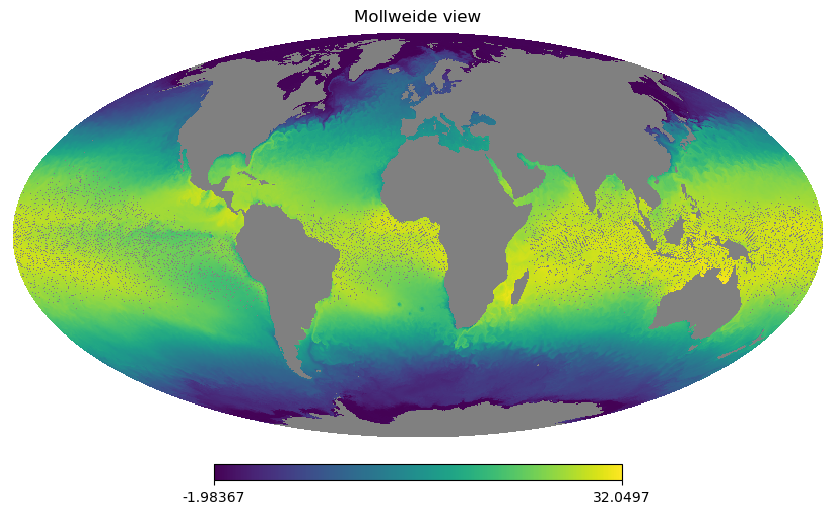

In [32]:
def get_nest(ds):
    return ds.crs.healpix_order == "ring"


healpy.mollview(ds_subset.avg_thetao, flip="geo", nest=get_nest(ds_subset))

In [56]:
model_run = cat.IFS['IFS_9-FESOM_5-production']['3D_daily_healpix512_ocean'].to_dask().pipe(attach_depth_coords)
model_run= add_healpix_crs(model_run)
model_run

<xarray.Dataset> Size: 95TB
Dimensions:     (time: 10816, level: 70, value: 3145728, crs: 1)
Coordinates:
  * time        (time) datetime64[ns] 87kB 2020-01-21 2020-01-22 ... 2050-01-01
  * level       (level) int64 560B 1 2 3 4 5 6 7 8 9 ... 63 64 65 66 67 68 69 70
    lon         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    lat         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    nz1         (level) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    nz          (level) int64 560B 0 5 10 15 20 25 ... 5150 5400 5650 6000 6350
  * crs         (crs) float64 8B nan
Dimensions without coordinates: value
Data variables:
    avg_uoe     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_wo      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_von     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_thetao  (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_so      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [58]:
def get_nside(ds):
    return ds.crs.attrs['healpix_nside']


# model_run = cat.IFS['IFS_9-FESOM_5-production']['3D_daily_healpix512_ocean']

# # ds_fine = model_run(zoom=10).to_dask()
# ds_fine=model_run
# hamburg = healpy.ang2pix(
#     get_nside(ds_fine), 9.993333, 53.550556, lonlat=True, nest=get_nest(ds_fine)
# )

# ds_fine.avg_thetao.isel(value=hamburg).plot(label="Hamburg")
# # model_run(zoom=0).to_dask().avg_thetao.mean("value").plot(label="global mean")
# plt.legend()

### Vertical Profile

In [106]:
lons = np.linspace(-60.0, 20.0, 200)
lats = np.full_like(lons, 0.0)

ds_subset = ds.isel(time=0)
ds_subset = add_healpix_crs(ds_subset)
ds_subset["lon"] = ds_subset["lon"].where(ds_subset["lon"] <= 180, other=ds_subset["lon"] - 360)


pnts = xr.DataArray(
    healpy.ang2pix(get_nside(ds_subset), lons, lats, lonlat=True, nest=get_nest(ds_subset)),
    dims=("value",),
    coords={"lon": (("value",), lons), "lat": (("value",), lats)},
)

pnts

<xarray.DataArray (value: 200)> Size: 2kB
array([1926758, 1926746, 1926741, 1926569, 1926565, 1926550, 1926506,
       1926502, 1926490, 1926485, 1923753, 1923749, 1923734, 1923690,
       1923686, 1923674, 1923669, 1923497, 1923493, 1923478, 1923434,
       1923430, 1923418, 1923413, 1922729, 1922725, 1922710, 1922666,
       1922662, 1922650, 1922645, 1922473, 1922469, 1922454, 1922410,
       1922406, 1922394, 1922389, 1223337, 1223333, 1223318, 1223274,
       1223270, 1223257, 1223253, 1223081, 1223077, 1223062, 1223018,
       1223014, 1223001, 1222997, 1222313, 1222309, 1222294, 1222250,
       1222246, 1222233, 1222229, 1222057, 1222053, 1222038, 1221994,
       1221990, 1221977, 1221973, 1219241, 1219237, 1219222, 1219178,
       1219174, 1219161, 1219157, 1218985, 1218981, 1218966, 1218922,
       1218918, 1218905, 1218901, 1218217, 1218213, 1218198, 1218154,
       1218150, 1218137, 1218133, 1217961, 1217957, 1217942, 1217898,
       1217894, 1217881, 1217877, 1206953, 1206949, 1206934, 1206890,
       1206886, 1206873, 1206869, 1206697, 1206693, 1206678, 1206634,
       1206630, 1206617, 1206613, 1205929, 1205925, 1205910, 1205866,
       1205862, 1205849, 1205845, 1205673, 1205669, 1205654, 1205610,
       1205606, 1205593, 1205589, 1202857, 1202853, 1202838, 1202794,
       1202790, 1202777, 1202773, 1202601, 1202597, 1202582, 1202538,
       1202534, 1202521, 1202517, 1201833, 1201829, 1201814, 1201770,
       1201766, 1201753, 1201749, 1201577, 1201573, 1201558, 1201514,
       1201510, 1201497, 1201493, 1157801, 1157786, 1157782, 1157738,
       1157734, 1157721, 1157717, 1157545, 1157530, 1157526, 1157482,
       1157478, 1157465, 1157461, 1156777, 1156762, 1156758, 1156714,
       1156710, 1156697, 1156693, 1156521, 1156506, 1156502, 1156458,
       1156454, 1156441, 1156437, 1153705, 1153690, 1153686, 1153642,
       1153638, 1153625, 1153621, 1153449, 1153434, 1153430, 1153386,
       1153382, 1153369, 1153365, 1152681, 1152666, 1152662, 1152618,
       1152614, 1152601, 1152597, 1152425])
Coordinates:
    lon      (value) float64 2kB -60.0 -59.6 -59.2 -58.79 ... 19.2 19.6 20.0
    lat      (value) float64 2kB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Dimensions without coordinates: value

In [108]:
ds_subset.avg_von.isel(value=pnts)

<xarray.DataArray 'avg_von' (level: 70, value: 200)> Size: 112kB
dask.array<getitem, shape=(70, 200), dtype=float64, chunksize=(1, 200), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B 2020-01-21
  * level    (level) int64 560B 1 2 3 4 5 6 7 8 9 ... 62 63 64 65 66 67 68 69 70
    lon      (value) float64 2kB -60.03 -59.68 -59.15 -58.8 ... 19.25 19.6 19.95
    lat      (value) float64 2kB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Dimensions without coordinates: value
Attributes: (12/14)
    paramId:                    263505
    dataType:                   fc
    numberOfPoints:             3145728
    typeOfLevel:                oceanModelLayer
    stepUnits:                  1
    stepType:                   avg
    ...                         ...
    units:                      m s**-1
    name:                       Time-mean northward sea water velocity
    cfVarName:                  avg_von
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150

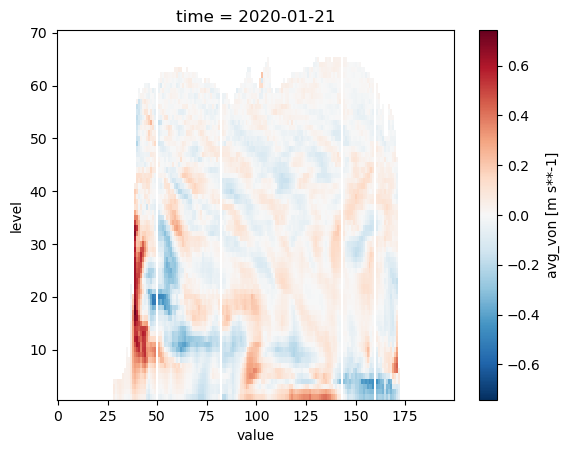

In [95]:
ds_subset.avg_von.isel(value=pnts).plot()

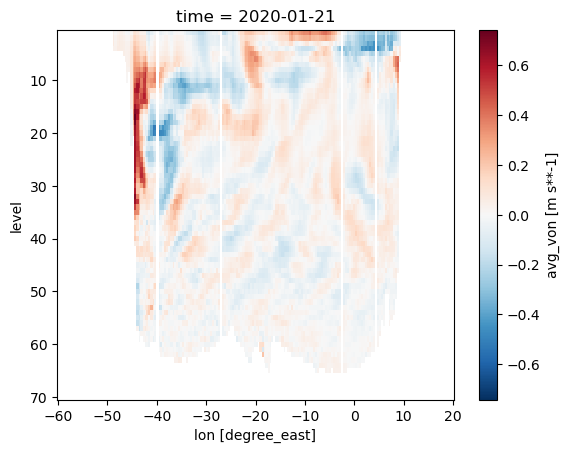

In [96]:
# ds_subset.avg_von.isel(value=pnts).swap_dims({"value": "lon"}).plot(x="lon", yincrease=False)
ds_subset.avg_von.isel(value=pnts).swap_dims({"value": "lon"}).plot(x="lon", yincrease=False)

## Plume Seasonality

In [154]:
def season_mean(data):

    ss = data['time'].dt.season
    ss_means = data.groupby(ss).mean('time')
    return ss_means

def monthly_mean(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [129]:
ds_subset = ds.isel(level=0)
ds_subset = add_healpix_crs(ds_subset)
ds_subset["lon"] = ds_subset["lon"].where(ds_subset["lon"] <= 180, other=ds_subset["lon"] - 360)
ds_subset

<xarray.Dataset> Size: 1TB
Dimensions:     (time: 10816, value: 3145728, crs: 1)
Coordinates:
  * time        (time) datetime64[ns] 87kB 2020-01-21 2020-01-22 ... 2050-01-01
    level       int64 8B 1
    lon         (value) float64 25MB 45.0 45.09 44.91 ... -44.91 -45.09 -45.0
    lat         (value) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
  * crs         (crs) float64 8B nan
Dimensions without coordinates: value
Data variables:
    avg_uoe     (time, value) float64 272GB dask.array<chunksize=(1, 3145728), meta=np.ndarray>
    avg_wo      (time, value) float64 272GB dask.array<chunksize=(1, 3145728), meta=np.ndarray>
    avg_von     (time, value) float64 272GB dask.array<chunksize=(1, 3145728), meta=np.ndarray>
    avg_thetao  (time, value) float64 272GB dask.array<chunksize=(1, 3145728), meta=np.ndarray>
    avg_so      (time, value) float64 272GB dask.array<chunksize=(1, 3145728), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [130]:
# 1. Define the Amazon plume region
lons = np.linspace(-75.0, -35.0, 200)  # from 75W to 35W
lats = np.linspace(-10.0, 30.0, 200)   # from 10S to 30N

# Make a meshgrid of the region (to get lat/lon pairs)
lon2d, lat2d = np.meshgrid(lons, lats)

# 2. Get Healpix pixel indices for the region
nside = get_nside(ds_subset)
nest = get_nest(ds_subset)

pixels = healpy.ang2pix(nside, lon2d.ravel(), lat2d.ravel(), lonlat=True, nest=nest)

# 3. Store in an xarray DataArray
pnts = xr.DataArray(
    pixels,
    dims=("value",),
    coords={
        "lon": (("value",), lon2d.ravel()),
        "lat": (("value",), lat2d.ravel()),
    },
    name="amazon_pixels"
)

In [134]:
sal_season = season_mean(ds_subset.sel(value=pnts.values).avg_so)
sal_season

<xarray.DataArray 'avg_so' (season: 4, value: 40000)> Size: 1MB
dask.array<stack, shape=(4, 40000), dtype=float64, chunksize=(1, 40000), chunktype=numpy.ndarray>
Coordinates:
    level    int64 8B 1
    lon      (value) float64 320kB -74.97 -74.79 -74.62 ... -35.42 -35.24 -35.07
    lat      (value) float64 320kB -10.05 -10.05 -10.05 ... 30.0 30.0 30.0
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: value
Attributes: (12/14)
    paramId:                    263500
    dataType:                   fc
    numberOfPoints:             3145728
    typeOfLevel:                oceanModelLayer
    stepUnits:                  1
    stepType:                   avg
    ...                         ...
    units:                      g kg**-1
    name:                       Time-mean sea water practical salinity
    cfVarName:                  avg_so
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150

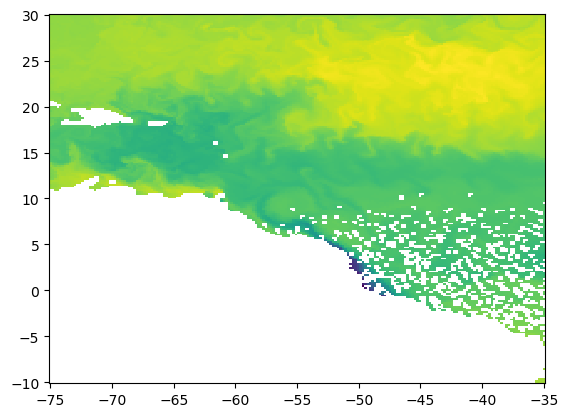

In [126]:
from scipy.interpolate import griddata

lons = np.linspace(-75.0, -35.0, 200)  # from 75W to 35W
lats = np.linspace(-10.0, 30.0, 200)   # from 10S to 30N

# Make a meshgrid of the region (to get lat/lon pairs)
lon2d, lat2d = np.meshgrid(lons, lats)

points = np.column_stack([lon2d.ravel(), lat2d.ravel()])

sal= ds_subset.isel(level=0).sel(value=pnts.values).avg_so.values
# sal_season = season_mean(ds_subset.sel(value=pnts.values).avg_so)

sal2d = griddata(
    points=points,
    values=sal,
    xi=(lon2d, lat2d),
    method='linear'  # or 'nearest'/'cubic'
)


plt.pcolormesh(lon2d,lat2d,sal2d)

In [138]:
season_names = ['DJF', 'MAM', 'JJA', 'SON']
sal_interp = []

for season in tqdm(season_names, desc="Interpolating all seasons"):
    sal = sal_season.sel(season=season).values
    sal2d = griddata(points, sal, (lon2d, lat2d), method='linear')
    sal_interp.append(sal2d)


# Convert to xarray Dataset
sal_interp = np.stack(sal_interp, axis=0)  # shape: (season, lat, lon)
sal_ds = xr.DataArray(
    data=sal_interp,
    dims=["season", "lat", "lon"],
    coords={
        "season": season_names,
        "lat": lats,
        "lon": lons
    },
    name="salinity"
)

Interpolating all seasons: 100%|██████████| 4/4 [02:10<00:00, 32.68s/it]


In [147]:
sal_ds

<xarray.DataArray 'salinity' (season: 4, lat: 200, lon: 200)> Size: 1MB
array([[[        nan,         nan,         nan, ..., 36.37136679,
         36.37977245, 36.39943351],
        [        nan,         nan,         nan, ..., 36.38846191,
         36.37233716, 36.3843369 ],
        [        nan,         nan,         nan, ..., 36.42275167,
         36.37208329, 36.36870942],
        ...,
        [36.9569364 , 36.95491459, 36.95590672, ..., 37.42162012,
         37.43474962, 37.44699432],
        [36.95307886, 36.95278016, 36.95173309, ..., 37.39006358,
         37.39175491, 37.40225377],
        [36.95036773, 36.95142246, 36.94903398, ..., 37.35717393,
         37.3498822 , 37.34608639]],

       [[        nan,         nan,         nan, ..., 36.07243171,
         36.06957684, 36.08263044],
        [        nan,         nan,         nan, ..., 36.06607199,
         36.0568809 , 36.06391571],
        [        nan,         nan,         nan, ..., 36.0687835 ,
         36.05061461, 36.0456142 ],
...
        [36.9115516 , 36.90358075, 36.90076516, ..., 37.68842838,
         37.69771028, 37.69648387],
        [36.87979608, 36.87975294, 36.87726984, ..., 37.66620951,
         37.66659123, 37.66643573],
        [36.86046944, 36.8582214 , 36.85938745, ..., 37.64335806,
         37.63518334, 37.63706872]],

       [[        nan,         nan,         nan, ..., 36.35741151,
         36.31894509, 36.28746373],
        [        nan,         nan,         nan, ..., 36.4547824 ,
         36.33086994, 36.3001619 ],
        [        nan,         nan,         nan, ..., 36.53060801,
         36.41024136, 36.32459633],
        ...,
        [36.81344082, 36.80336994, 36.80050311, ..., 37.78287879,
         37.80745393, 37.81165901],
        [36.8049775 , 36.80076945, 36.79480786, ..., 37.74738832,
         37.74894436, 37.77728224],
        [36.79819669, 36.79412753, 36.78731124, ..., 37.71779411,
         37.70553925, 37.70858832]]], shape=(4, 200, 200))
Coordinates:
  * season   (season) <U3 48B 'DJF' 'MAM' 'JJA' 'SON'
  * lat      (lat) float64 2kB -10.0 -9.799 -9.598 -9.397 ... 29.6 29.8 30.0
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -35.4 -35.2 -35.0

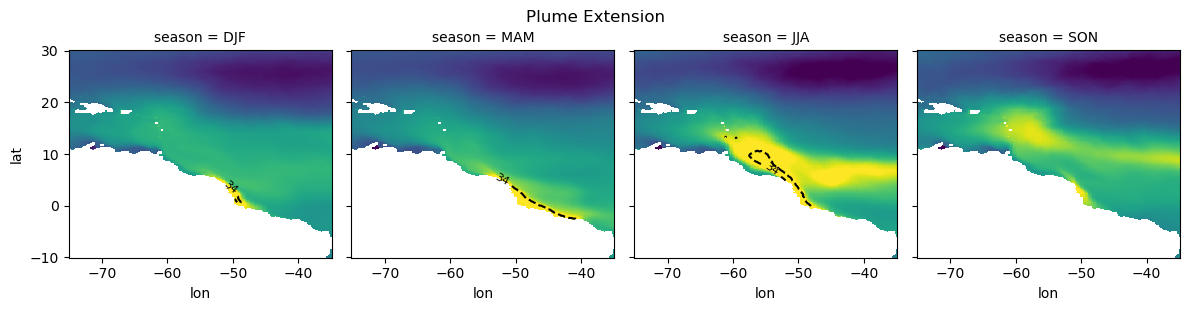

In [153]:
g = sal_ds.plot(col="season", col_wrap=4, robust=True, 
                                     figsize=(12, 3),cmap='viridis_r',add_colorbar=False)

# Add 30 psu contour lines to each subplot
for ax, season in zip(g.axs.flat, sal_ds.season.values):  # Use g.axs instead of g.axes
    # Select 2D data for this specific season
    season_data = sal_ds.sel(season=season)
    
    # Squeeze to ensure 2D (remove any singleton dimensions)
    contour_data = season_data.squeeze()
    
    # Plot contour
    cs = ax.contour(
        contour_data.lon, 
        contour_data.lat, 
        contour_data,
        levels=[34],
        colors='black',
        linewidths=1.5,
        linestyles='--'
    )
    # Optional: Add contour labels
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.f')

# Adjust layout and add title
plt.suptitle("Plume Extension", y=1.02)
# plt.tight_layout()
# plt.savefig('Figures/Sal_season'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()